# YouTube Scraping & NLP Analysis Tutorial
This notebook scrapes top YouTube videos, extracts transcripts using SerpApi, cleans text, performs NLP, creates visualizations, word clouds, topic modeling, and generates a final content analysis report.

## Install Libraries

In [ ]:
%pip install google-search-results nltk scikit-learn matplotlib seaborn pandas wordcloud

## SSL Fix (Optional)

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## NLTK Downloads

In [3]:
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/noraina/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/noraina/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load API Key

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
API_KEY = os.getenv('SERPAPI_API_KEY')

## Scrape YouTube Search Results

In [5]:
from serpapi import GoogleSearch
import pandas as pd

def search_top_videos(query, api_key, max_results=5):
    params = {
        'engine': 'youtube',
        'search_query': query,
        'gl': 'us',
        'api_key': api_key
    }
    search = GoogleSearch(params)
    results = search.get_dict()
    videos = results.get('video_results', [])[:max_results]

    output = []
    for v in videos:
        link = v.get('link', '')
        video_id = None
        if 'v=' in link:
            video_id = link.split('v=')[1].split('&')[0]

        output.append({
            'title': v.get('title'),
            'video_id': video_id,
            'link': link,
            'channel': v.get('channel', {}).get('name'),
            'views': v.get('views'),
            'published': v.get('published_date')
        })
    return pd.DataFrame(output)

topic = "python tutorial for beginners"
df_videos = search_top_videos(topic, API_KEY)
df_videos

,title,video_id,link,channel,views,published
0,Python for Beginners - Learn Coding with Pytho...,kqtD5dpn9C8,https://www.youtube.com/watch?v=kqtD5dpn9C8,Programming with Mosh,23126393,5 years ago
1,Python Full Course for Beginners [2025],K5KVEU3aaeQ,https://www.youtube.com/watch?v=K5KVEU3aaeQ,Programming with Mosh,4253984,9 months ago
2,Python Full Course for Beginners,_uQrJ0TkZlc,https://www.youtube.com/watch?v=_uQrJ0TkZlc,Programming with Mosh,46285019,6 years ago
3,👩‍💻 Python for Beginners Tutorial,b093aqAZiPU,https://www.youtube.com/watch?v=b093aqAZiPU,Kevin Stratvert,4112731,4 years ago
4,Learn Python in Less than 10 Minutes for Begin...,fWjsdhR3z3c,https://www.youtube.com/watch?v=fWjsdhR3z3c,Indently,1096854,4 years ago


## Scrape Transcripts

In [6]:
def fetch_transcript(video_id, api_key):
    params = {
        'api_key': api_key,
        'engine': 'youtube_video_transcript',
        'v': video_id,
        'language_code': 'en',
        'type': 'asr'
    }
    results = GoogleSearch(params).get_dict()
    transcript = results.get('transcript', [])
    if not transcript:
        return ''
    return ' '.join([t.get('snippet', '') for t in transcript])

df_videos['transcript'] = df_videos['video_id'].apply(lambda x: fetch_transcript(x, API_KEY))
df_videos

,title,video_id,link,channel,views,published,transcript
0,Python for Beginners - Learn Coding with Pytho...,kqtD5dpn9C8,https://www.youtube.com/watch?v=kqtD5dpn9C8,Programming with Mosh,23126393,5 years ago,in this python tutorial you're going to learn ...
1,Python Full Course for Beginners [2025],K5KVEU3aaeQ,https://www.youtube.com/watch?v=K5KVEU3aaeQ,Programming with Mosh,4253984,9 months ago,[Music] welcome to the complete python Mastery...
2,Python Full Course for Beginners,_uQrJ0TkZlc,https://www.youtube.com/watch?v=_uQrJ0TkZlc,Programming with Mosh,46285019,6 years ago,hi my name is mosh and i'm going to be your in...
3,👩‍💻 Python for Beginners Tutorial,b093aqAZiPU,https://www.youtube.com/watch?v=b093aqAZiPU,Kevin Stratvert,4112731,4 years ago,hey everyone kevin here today i want to show y...
4,Learn Python in Less than 10 Minutes for Begin...,fWjsdhR3z3c,https://www.youtube.com/watch?v=fWjsdhR3z3c,Indently,1096854,4 years ago,what is up guys in this video i'm going to be ...


## Clean & Preprocess Text

In [7]:
import re
from nltk.corpus import stopwords

custom_stopwords = {
    "let","get","one","thing","want","going","got",
    "use","used","using","make","like","really",
    "look","see","know","right","okay","ok",
    "say","says","said","think","thought"
}

stop_words = set(stopwords.words("english")).union(custom_stopwords)

def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df_videos['clean_text'] = df_videos['transcript'].apply(clean_text)
df_videos[['title','clean_text']].head()

,title,clean_text
0,Python for Beginners - Learn Coding with Pytho...,python tutorial learn everything need start pr...
1,Python Full Course for Beginners [2025],music welcome complete python mastery course c...
2,Python Full Course for Beginners,name mosh instructor python course course lear...
3,👩‍💻 Python for Beginners Tutorial,hey everyone kevin today show fundamentals pro...
4,Learn Python in Less than 10 Minutes for Begin...,guys video showing started python less minutes...


The cleaned text removes filler words and punctuation so that our NLP models focus on meaningful content. 
This helps improve sentiment analysis accuracy and makes TF-IDF and topic modeling more reliable.

## Sentiment Analysis

In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text:
        return 0
    return sia.polarity_scores(text)['compound']

df_videos['sentiment'] = df_videos['clean_text'].apply(get_sentiment)
df_videos[['title','sentiment']]

,title,sentiment
0,Python for Beginners - Learn Coding with Pytho...,0.9998
1,Python Full Course for Beginners [2025],1.0000
2,Python Full Course for Beginners,1.0000
3,👩‍💻 Python for Beginners Tutorial,0.9999
4,Learn Python in Less than 10 Minutes for Begin...,0.9985


## TF-IDF Keyword Extraction

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform(df_videos['clean_text'])
keywords = vectorizer.get_feature_names_out()

df_keywords = pd.DataFrame(tfidf_matrix.toarray(), columns=keywords)
df_keywords['title'] = df_videos['title']
df_keywords

,add,also,call,code,first,function,list,name,need,number,...,program,python,run,set,string,two,type,value,variable,title
0,0.109868,0.137335,0.119075,0.233470,0.164802,0.228892,0.219736,0.054934,0.132757,0.160224,...,0.224314,0.476096,0.196847,0.100713,0.361650,0.123602,0.247203,0.242626,0.242626,Python for Beginners - Learn Coding with Pytho...
1,0.156831,0.091936,0.134273,0.470494,0.148719,0.243359,0.043264,0.086528,0.102752,0.173055,...,0.289327,0.511054,0.232543,0.081120,0.256879,0.186575,0.137903,0.127087,0.137903,Python Full Course for Beginners [2025]
2,0.249843,0.142170,0.223709,0.250888,0.213255,0.310474,0.214300,0.187121,0.288521,0.127535,...,0.319882,0.303156,0.238344,0.202801,0.176667,0.216391,0.159941,0.158896,0.134852,Python Full Course for Beginners
3,0.058138,0.211788,0.137475,0.448492,0.078901,0.427729,0.008305,0.116276,0.074749,0.049832,...,0.016611,0.336369,0.269926,0.020764,0.024916,0.132887,0.423576,0.132887,0.203483,👩‍💻 Python for Beginners Tutorial
4,0.369835,0.197245,0.000000,0.123278,0.073967,0.147934,0.098623,0.271213,0.147934,0.221901,...,0.320524,0.197245,0.172590,0.024656,0.221901,0.123278,0.419147,0.197245,0.024656,Learn Python in Less than 10 Minutes for Begin...


## Topic Modeling (LDA)

In [10]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda_topics = lda.fit_transform(tfidf_matrix)

df_videos[['Topic 1','Topic 2','Topic 3']] = lda_topics
df_videos

,title,video_id,link,channel,views,published,transcript,clean_text,sentiment,Topic 1,Topic 2,Topic 3
0,Python for Beginners - Learn Coding with Pytho...,kqtD5dpn9C8,https://www.youtube.com/watch?v=kqtD5dpn9C8,Programming with Mosh,23126393,5 years ago,in this python tutorial you're going to learn ...,python tutorial learn everything need start pr...,0.9998,0.068245,0.068245,0.863511
1,Python Full Course for Beginners [2025],K5KVEU3aaeQ,https://www.youtube.com/watch?v=K5KVEU3aaeQ,Programming with Mosh,4253984,9 months ago,[Music] welcome to the complete python Mastery...,music welcome complete python mastery course c...,1.0000,0.071640,0.071640,0.856720
2,Python Full Course for Beginners,_uQrJ0TkZlc,https://www.youtube.com/watch?v=_uQrJ0TkZlc,Programming with Mosh,46285019,6 years ago,hi my name is mosh and i'm going to be your in...,name mosh instructor python course course lear...,1.0000,0.064944,0.064944,0.870111
3,👩‍💻 Python for Beginners Tutorial,b093aqAZiPU,https://www.youtube.com/watch?v=b093aqAZiPU,Kevin Stratvert,4112731,4 years ago,hey everyone kevin here today i want to show y...,hey everyone kevin today show fundamentals pro...,0.9999,0.077132,0.077132,0.845736
4,Learn Python in Less than 10 Minutes for Begin...,fWjsdhR3z3c,https://www.youtube.com/watch?v=fWjsdhR3z3c,Indently,1096854,4 years ago,what is up guys in this video i'm going to be ...,guys video showing started python less minutes...,0.9985,0.072135,0.072135,0.855730


## Assign Topic Labels

In [11]:
topic_labels = {
    0: "Python Basics",
    1: "Data Analysis Concepts",
    2: "Hands-on Coding/Projects"
}

df_videos['Dominant Topic'] = df_videos[['Topic 1','Topic 2','Topic 3']].values.argmax(axis=1)
df_videos['Topic Label'] = df_videos['Dominant Topic'].map(topic_labels)

df_videos[['title','Topic Label']]

,title,Topic Label
0,Python for Beginners - Learn Coding with Pytho...,Hands-on Coding/Projects
1,Python Full Course for Beginners [2025],Hands-on Coding/Projects
2,Python Full Course for Beginners,Hands-on Coding/Projects
3,👩‍💻 Python for Beginners Tutorial,Hands-on Coding/Projects
4,Learn Python in Less than 10 Minutes for Begin...,Hands-on Coding/Projects


## Visualizations

### Bar Chart

/Users/noraina/Documents/works/src/python_project/youtube_analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128105 (\N{WOMAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/noraina/Documents/works/src/python_project/youtube_analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


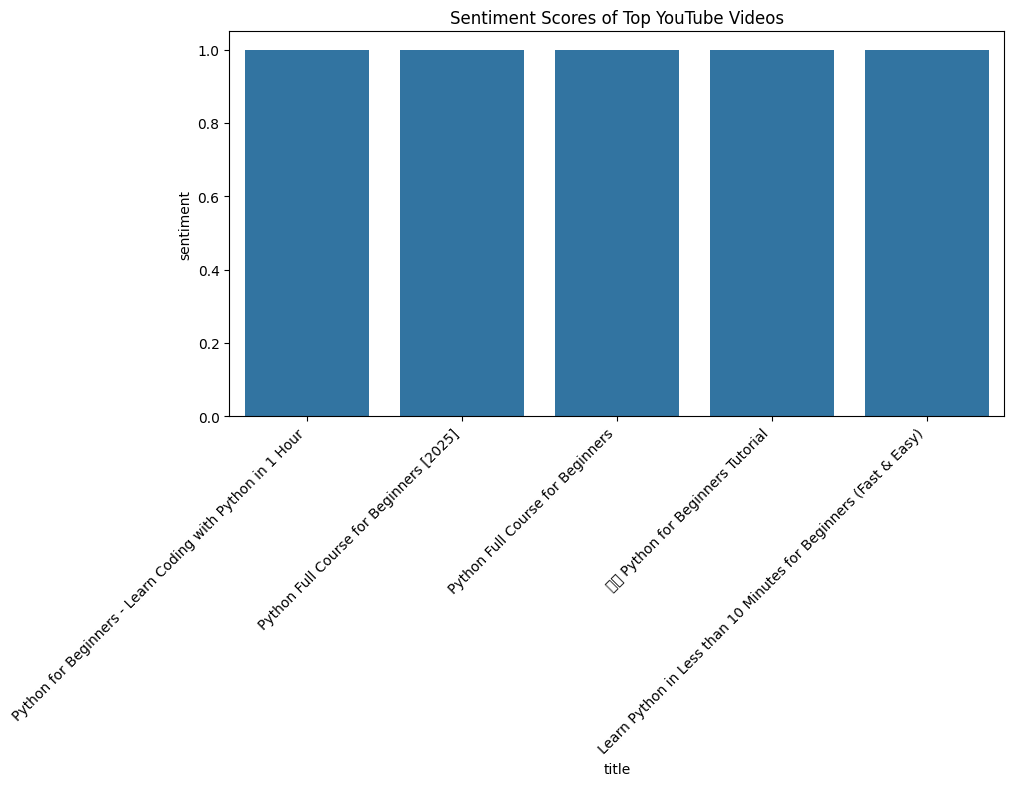

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=df_videos, x="title", y="sentiment")
plt.xticks(rotation=45, ha="right")
plt.title("Sentiment Scores of Top YouTube Videos")
plt.show()

Higher sentiment scores indicate a more positive and friendly teaching tone.
Most of the top-ranking videos show strongly positive sentiment,
suggesting that tone may influence viewer engagement.

### Heatmap

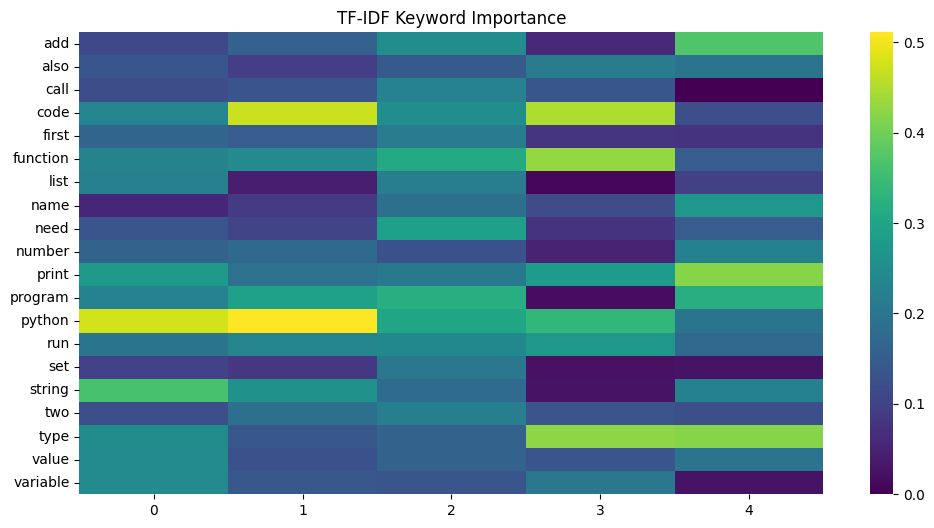

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(df_keywords.drop(columns=['title']).T, cmap='viridis')
plt.title("TF-IDF Keyword Importance")
plt.show()

### Word Cloud

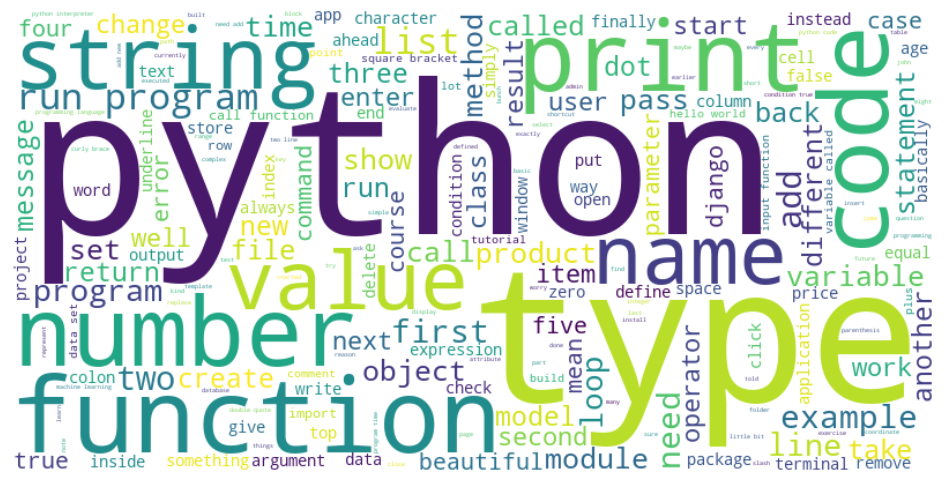

In [14]:
from wordcloud import WordCloud

all_text = ' '.join(df_videos['clean_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

## Final Report

In [15]:
for idx, row in df_videos.iterrows():
    print("="*60)
    print(f"Title: {row['title']}")
    print(f"Channel: {row['channel']}")
    print(f"Sentiment Score: {row['sentiment']:.3f}")
    print(f"Top Keywords: {df_keywords.drop(columns=['title']).iloc[idx].nlargest(5).index.tolist()}")

Title: Python for Beginners - Learn Coding with Python in 1 Hour
Channel: Programming with Mosh
Sentiment Score: 1.000
Top Keywords: ['python', 'string', 'print', 'type', 'value']
Title: Python Full Course for Beginners [2025]
Channel: Programming with Mosh
Sentiment Score: 1.000
Top Keywords: ['python', 'code', 'program', 'string', 'function']
Title: Python Full Course for Beginners
Channel: Programming with Mosh
Sentiment Score: 1.000
Top Keywords: ['program', 'function', 'python', 'need', 'code']
Title: 👩‍💻 Python for Beginners Tutorial
Channel: Kevin Stratvert
Sentiment Score: 1.000
Top Keywords: ['code', 'function', 'type', 'python', 'print']
Title: Learn Python in Less than 10 Minutes for Beginners (Fast & Easy)
Channel: Indently
Sentiment Score: 0.999
Top Keywords: ['print', 'type', 'add', 'program', 'name']
